<h1 style="font-size:40px;">GLM Model</h1>

<p style="font-size:18px">Generalized Linear Models (GLMs) are powerful tools for statistical modeling. They extend
linear regression to response variables that follow non-normal distributions by assuming the
response variable belongs to the exponential family of distributions. In this framework, the
expected value of the response variable is related to a linear combination of input covariates
through a suitable link function.<p>

<p style="font-size:25px">Libraries</p>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
import statsmodels.api as sm
import time
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

<h2 style="font-size:35px;">Data Observations</h2>

<p style="font-size:18px">Before building the model, I explored the dataset to better understand its characteristics. I first examined the summary statistics to identify the range and distribution of each variable.And then I plotted a histogram of the response variable to determine whether it was positive and right-skewed. Finally, I created scatter plots between each predictor and the response variable to investigate the relationships and to assess whether the variance appeared to increase with the mean.</p>

In [3]:
data = pd.read_csv(r'D:\projects\UniversityProjects\University\NLP\CA2_NLP\gamma.csv')

data.head()

,x1,x2,x3,x4,x5,y
0,3.352058,2.083493,0.575296,0.532679,1,14.457383
1,3.796435,1.854274,0.595645,1.158138,1,7.337961
2,1.752608,2.938654,0.458634,1.122724,0,1.637679
3,1.175234,2.236772,1.035738,2.108895,1,9.099828
4,1.820076,3.102281,0.692244,-2.329294,1,1.321441


<p style="font-size:18px">As you can see, we have three columns such that first five collumns are predictors and the last column is our RV.</p>

In [22]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      1000 non-null   float64
 1   x2      1000 non-null   float64
 2   x3      1000 non-null   float64
 3   x4      1000 non-null   float64
 4   x5      1000 non-null   int64  
 5   y       1000 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 47.0 KB
None


In [23]:
print(data.describe())

                x1           x2           x3           x4           x5  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      3.025433     3.010198     0.794704     0.015902     0.589000   
std       1.112182     1.000166     0.394290     0.981481     0.492261   
min       1.000134     0.096149     0.102044    -3.525616     0.000000   
25%       2.047172     2.314324     0.468677    -0.636760     0.000000   
50%       3.017641     3.025743     0.796198    -0.028035     1.000000   
75%       3.972503     3.691170     1.131596     0.698384     1.000000   
max       4.998965     7.402141     1.497384     3.045147     1.000000   

                 y  
count  1000.000000  
mean      6.653052  
std       8.844500  
min       0.105442  
25%       1.925859  
50%       3.691055  
75%       7.587637  
max      87.750251  


<p style="font-size:18px">Uhhhh...!</p>
<p style="font-size:18px">These numbers are not obvious, but we'll take care of that with sketching plots.</p>

<p style="font-size:25px">DATA OBSERVATION</p>

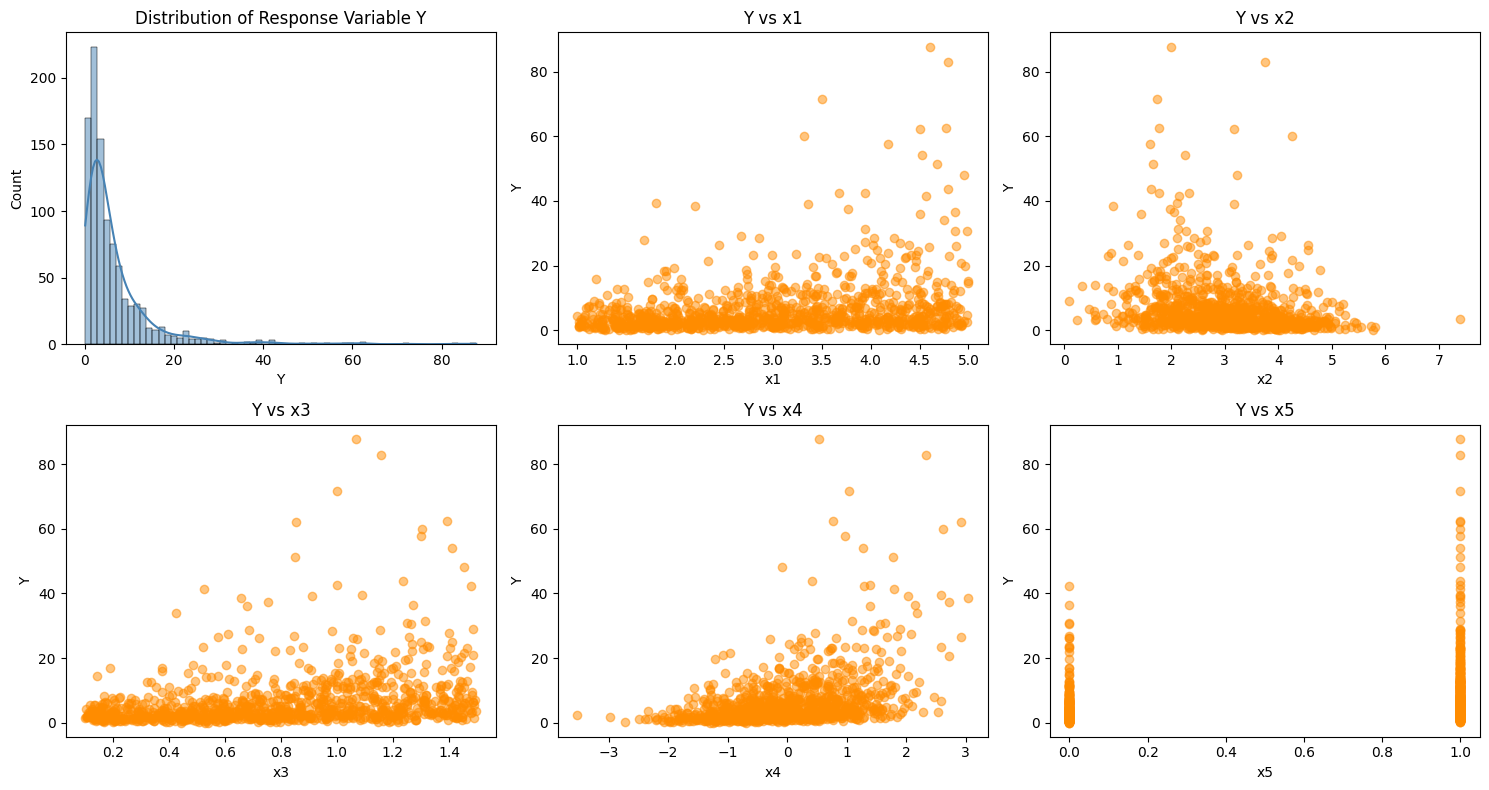

In [ ]:
y_col = "y"
x_cols = [c for c in data.columns if c != y_col]

fig, axes = plt.subplots(2, 3, figsize=(15,8))

axes = axes.flatten()

#Histogram / KDE of Y
sns.histplot(data[y_col], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Response Variable Y")
axes[0].set_xlabel("Y")

#Scatter of Y vs each predictor
for i, col in enumerate(x_cols):
    axes[i + 1].scatter(data[col], data[y_col], alpha=0.5, color="darkorange")
    axes[i + 1].set_title(f"Y vs {col}")
    axes[i + 1].set_xlabel(col)
    axes[i + 1].set_ylabel("Y")

plt.tight_layout()
plt.show()

X = np.column_stack([np.ones(len(data)), data[x_cols].values])
Y = data[y_col].values
n, p = X.shape

<p style="font-size:18px">As you can see. Plots suggest that the assumptions of Ordinary Least Squares(OLS) are violated. OLS assumes normally distributed errors, constant variance, and a linear relationship between the predictors and the response. However, the response variable in this dataset is strictly positive, right-skewed, and its variance increases as the mean increases. These characteristics make Gamma Regression a more appropriate modeling approach.</p>
<p style="font-size:18px">In Gamma Regression, we assume that each response variable follows a Gamma distribution. Instead of modeling the response directly, we model its expected value. The logarithmic link function relates the expected response to a linear combination of the predictors. Taking the exponential of this linear predictor ensures that all predicted values remain positive, which is an essential requirement for Gamma-distributed data.</p>

<p style="font-size:18px">According to appendix A of project we assume that NLL is computed also in appendix we've re named NLL as NLL2 but here we will call NLL2 as NLL</p>

<p style="font-size:25px">NLL, Gradient, Hessian</p>

In [23]:
def GammaNLL( beta,X, y,nu = 1):
    v = np.dot(X, beta)
    mu = np.exp(v)
    nll = nu * np.sum(v + (y/mu))
    return nll

def NLLGradient( beta,X, y, nu=1):
    v = np.dot(X, beta)
    mu = np.exp(v)
    gradient = nu * np.dot(X.T, (1 - (y/mu)))
    return gradient

def NLLHessian(beta, X, y):
    z = X @ beta
    w = y * np.exp(-z)
    return X.T @ (X * w[:, None])

<h3 style="font-size:25px">Constant Stepsize Gradient method</h3>

In [54]:
def CGD(X, y, lr=1e-5, tol=1e-6, max_iter=200000):
    loss_history, Train_Record = [],[]
    beta = np.zeros(X.shape[1])
    Gradient = NLLGradient(beta,X, y)
    NLL_init_value = GammaNLL(beta,X, y)
    t = 0
    while np.linalg.norm(Gradient) > tol and t<max_iter:
        loss_history.append(NLL_init_value)
        beta = beta - lr * Gradient
        NLL_init_value = GammaNLL(beta,X, y)
        Gradient = NLLGradient(beta,X, y)
        Train_Record.append([NLL_init_value, np.linalg.norm(Gradient)])
        t+=1
    Train_Record = pd.DataFrame(Train_Record, columns=['NLL', 'Gradient Norm'])
    loss_history = pd.DataFrame(loss_history, columns=['NLL'])
    return beta, loss_history, Train_Record


<h3 style="font-size:25px">Newton Raphson method</h3>

In [55]:
def NewtonRaphson(X, y, tol=1e-12, max_iter=1000):
    loss_history, Train_Record = [],[]
    t = 0
    beta = np.zeros(X.shape[1])
    Gradient = NLLGradient(beta, X, y)
    NLL_init_value = GammaNLL(beta,X, y)
    while np.linalg.norm(Gradient) > tol and t < max_iter:
        loss_history.append(NLL_init_value)
        H = NLLHessian(beta, X, y)
        delta = np.linalg.solve(H, Gradient)
        beta = beta - delta
        Gradient = NLLGradient(beta, X, y)
        NLL_init_value = GammaNLL(beta,X, y)
        Train_Record.append([NLL_init_value, np.linalg.norm(Gradient)])
        t+=1
    Train_Record = pd.DataFrame(Train_Record, columns=['NLL', 'Gradient Norm'])
    loss_history = pd.DataFrame(loss_history, columns=['NLL'])
    return beta, loss_history,Train_Record

<h3 style="font-size:25px">CVX</h3>

In [56]:
def CVX(X, y):
    p = X.shape[1]
    beta_var = cp.Variable(p)
    z = X @ beta_var
    objective_expr = cp.sum(z) + cp.sum(cp.multiply(y, cp.exp(-z)))
    problem = cp.Problem(cp.Minimize(objective_expr))
    problem.solve()
    return beta_var.value

<h3 style="font-size:25px">Built-in STATSMODELS</h3>

In [64]:
def fit_statsmodels(X, y):
    model = sm.GLM(y, X, family=sm.families.Gamma(link=sm.families.links.Log()))
    result = model.fit()
    return result.params, result

<h3 style="font-size:25px">MODEL COMPARISON</h3>


FITTING ALL METHODS ON FULL DATASET


C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


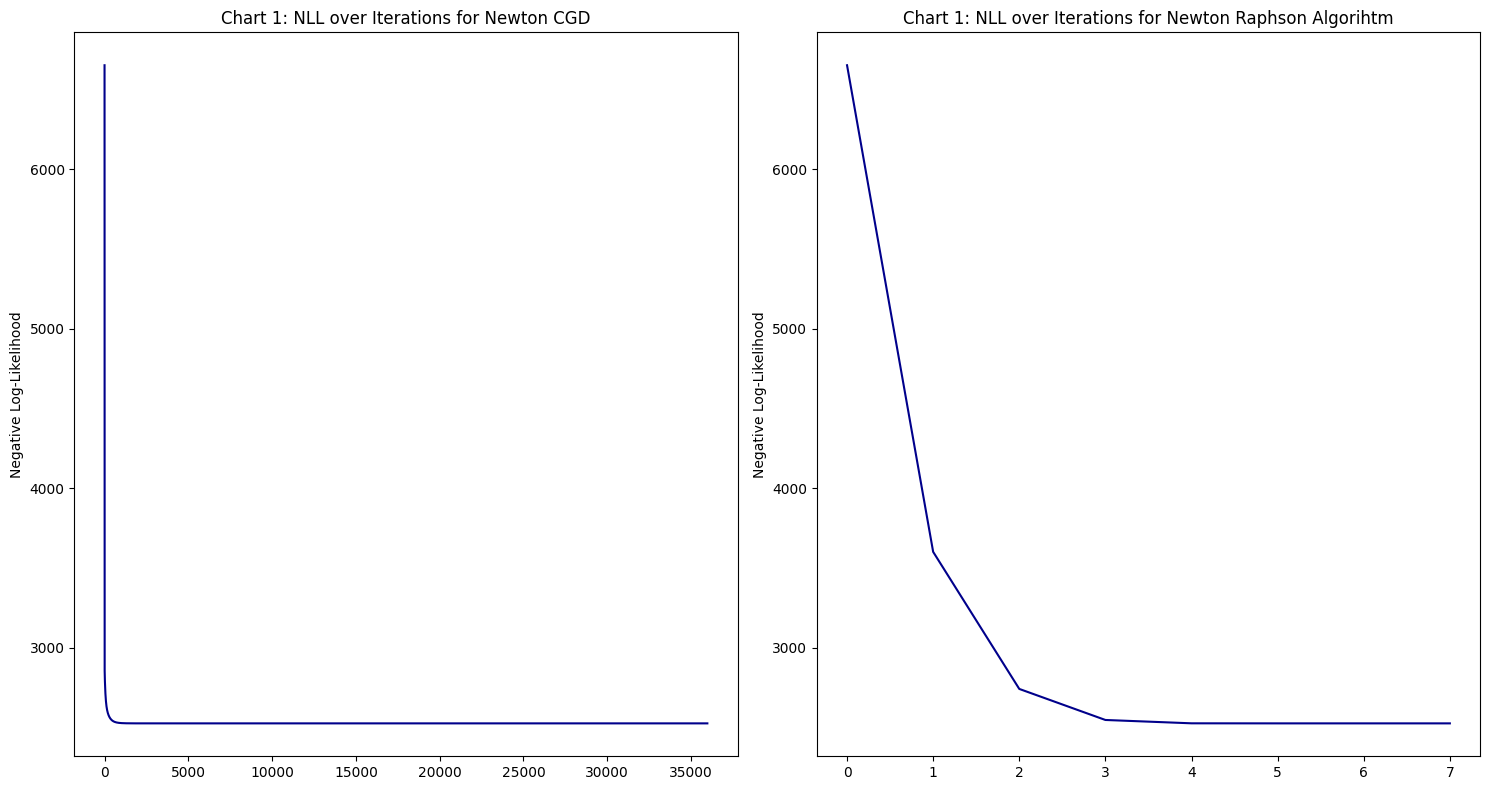



Coefficient comparison across methods:

Coefficient     cvxpy  Gradient Descent  Newton-Raphson  statsmodels GLM
  Intercept  0.278250          0.278253        0.278253         0.278253
         x1  0.300546          0.300546        0.300546         0.300546
         x2 -0.285046         -0.285047       -0.285047        -0.285047
         x3  0.941103          0.941102        0.941102         0.941102
         x4  0.491977          0.491976        0.491976         0.491976
         x5  0.750222          0.750221        0.750221         0.750221

Constant Step Size Gradient Method: Iterations: 35973  Solve Time:0.9610s
Newton Raphson Method: Iterations: 8  Solve Time:0.0000s
cvxpy solve time: 0.0728s
statsmodels fit time: 0.0019s


In [77]:
print("\n" + "=" * 85)
print("FITTING ALL METHODS ON FULL DATASET")
print("=" * 85)

t0 = time.time()
beta_cvxpy = CVX(X, Y)
t_cvxpy = time.time() - t0

t0 = time.time()

beta1, loss_history1, Train_Record1 = CGD(X, Y)
t_gd = time.time() - t0

t0 = time.time()
beta2, loss_history2, Train_Record2 = NewtonRaphson(X, Y)
t_nr = time.time() - t0

fig, axes = plt.subplots(1, 2, figsize=(15,8))

axes = axes.flatten()

axes[0].plot(loss_history1['NLL'],color='DarkBlue')
axes[0].set_title('Chart 1: NLL over Iterations for Newton CGD')
axes[0].set_ylabel('Negative Log-Likelihood')

axes[1].plot(loss_history2['NLL'],color='DarkBlue')
axes[1].set_title('Chart 1: NLL over Iterations for Newton Raphson Algorihtm')
axes[1].set_ylabel('Negative Log-Likelihood')

plt.tight_layout()
plt.show()

t0 = time.time()
beta_sm, sm_result = fit_statsmodels(X, Y)
t_sm = time.time() - t0

coef_names = ["Intercept"] + x_cols
comparison_df = pd.DataFrame({
    "Coefficient": coef_names,
    "cvxpy": beta_cvxpy,
    "Gradient Descent": beta1,
    "Newton-Raphson": beta2,
    "statsmodels GLM": beta_sm,
})
print("\n\nCoefficient comparison across methods:\n")
print(comparison_df.to_string(index=False))
print(f"\nConstant Step Size Gradient Method: Iterations: {len(loss_history1)}  Solve Time:{t_gd:.4f}s")
print(f"Newton Raphson Method: Iterations: {len(loss_history2)}  Solve Time:{t_nr:.4f}s")
print(f"cvxpy solve time: {t_cvxpy:.4f}s")
print(f"statsmodels fit time: {t_sm:.4f}s")

<h3 style="font-size:25px">EVALUATION METRICS</h3>

In [78]:
def MeanPredictor(beta, X):
    return np.exp(X @ beta)


def RMSE(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def Adjusted_R2(y_true, y_pred, n_predictors):
    n = len(y_true)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    denom = (n - n_predictors - 1)
    if denom <= 0:
        return np.nan
    adj_r2 = 1 - (1 - r2) * (n - 1) / denom
    return adj_r2

<h3 style="font-size:25px">10 FOLD CROSS-VALIDATION COMPARISON OF ALL METHODS</h3>

In [79]:
print("\n" + "=" * 85)
print("10-FOLD CROSS-VALIDATION")
print("=" * 85)

kf = KFold(n_splits=10, shuffle=True, random_state=42)

methods = {
    "cvxpy": CVX,
    "Gradient Descent": lambda Xtr, ytr: CGD(Xtr, ytr)[0],
    "Newton-Raphson": lambda Xtr, ytr: NewtonRaphson(Xtr, ytr)[0],
    "statsmodels GLM": lambda Xtr, ytr: fit_statsmodels(Xtr, ytr)[0],
}

cv_results = {name: {"adj_r2": [], "rmse": [], "time": []} for name in methods}

fold_num = 0
for train_idx, test_idx in kf.split(X):
    fold_num += 1
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = Y[train_idx], Y[test_idx]

    for name, fit_fn in methods.items():
        t0 = time.time()
        beta_hat = fit_fn(X_train, y_train)
        elapsed = time.time() - t0

        y_pred = MeanPredictor(beta_hat, X_test)
        rmse = RMSE(y_test, y_pred)
        adj_r2 = Adjusted_R2(y_test, y_pred, n_predictors=X.shape[1] - 1)

        cv_results[name]["adj_r2"].append(adj_r2)
        cv_results[name]["rmse"].append(rmse)
        cv_results[name]["time"].append(elapsed)
        
summary_rows = []
for name, metrics in cv_results.items():
    summary_rows.append({
        "Method": name,
        "Mean Adjusted R2": np.nanmean(metrics["adj_r2"]),
        "Std Adjusted R2": np.nanstd(metrics["adj_r2"]),
        "Mean RMSE": np.mean(metrics["rmse"]),
        "Std RMSE": np.std(metrics["rmse"]),
        "Mean Fit Time (s)": np.mean(metrics["time"]),
    })

cv_summary_df = pd.DataFrame(summary_rows)
print("\n10-Fold Cross-Validation Summary:")
print(cv_summary_df.to_string(index=False))

cv_summary_df.to_csv("GLMsummary.csv", index=False)
comparison_df.to_csv("GLM_coefficient_comparison.csv", index=False)
print("\nSaved 'GLMsummary.csv' and 'GLM_coefficient_comparison.csv'")


10-FOLD CROSS-VALIDATION

10-Fold Cross-Validation Summary:
          Method  Mean Adjusted R2  Std Adjusted R2  Mean RMSE  Std RMSE  Mean Fit Time (s)
           cvxpy          0.518684         0.198125   5.392735  1.420512           0.030521
Gradient Descent          0.518684         0.198125   5.392733  1.420511           1.119438
  Newton-Raphson          0.518684         0.198125   5.392733  1.420511           0.001683
 statsmodels GLM          0.518684         0.198125   5.392733  1.420511           0.002730

Saved 'GLMsummary.csv' and 'GLM_coefficient_comparison.csv'
